# EDA 


- **Autores:** 
    - Vanessa Romero Aguirre
    -
    -
    
- **Última actualización:** 18/08/2026

## 1. Introducción
### Análisis Exploratorio de Datos (EDA)

El objetivo de este análisis es básicamente entender el dataset de reservas hoteleras antes de desarrollar los modelos de Machine Learning.

Hemos determinado que la variable objetivo será is_canceled, que indica si una reserva fue cancelada:

- 0 → Reserva no cancelada
- 1 → Reserva cancelada

Durante este análisis queremos identificar posibles problemas de valores nulos, valores atípicos, variables categóricas y posibles casos de fuga de datos.

## 2. Importación de librerías

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.datasets import load_diabetes, load_iris, load_wine
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from typing import List, Optional, Tuple, Union
from xgboost import XGBClassifier, XGBRegressor

## 3. Carga del dataset

In [4]:
PATH_DIRECTORIO_DATOS = "../data"

In [5]:
PATH_DATASET_HOTEL = f"{PATH_DIRECTORIO_DATOS}/dataset_practica_final.csv"

### Definición de funciones

In [6]:
# Calculamos las métricas de evaluación
def calcular_metricas_evaluacion(y_prediccion: np.ndarray, y_real: np.ndarray, verbose: bool = True):
    """Calcula las métricas de evaluación para un modelo de regresión.
    
    Calcula cuatro métricas comunes para evaluar modelos de regresión: MSE (Error Cuadrático Medio),
    RMSE (Raíz del Error Cuadrático Medio), MAE (Error Absoluto Medio) y R² (Coeficiente de determinación).
    Opcionalmente imprime los resultados en un formato legible.
    
    Args:
        y_prediccion (np.ndarray): Valores predichos por el modelo.
        y_real (np.ndarray): Valores reales observados.
        verbose (bool, optional): Si es True, imprime las métricas calculadas. Por defecto es True.
    
    Returns:
        tuple[float, float, float, float]: Una tupla con cuatro valores en el siguiente orden:
            - mse: Error cuadrático medio.
            - rmse: Raíz del error cuadrático medio.
            - mae: Error absoluto medio.
            - r2: Coeficiente de determinación.
    
    Example:
        >>> mse, rmse, mae, r2 = calcular_metricas_evaluacion(modelo.predict(X_test), y_test)
        >>> print(f"R²: {r2:.4f}")
    """
    
    mse = mean_squared_error(y_real, y_prediccion)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_prediccion)
    r2 = r2_score(y_real, y_prediccion)

    if verbose:
        print("\nEvaluación del modelo:")
        print(f"MSE (Error cuadrático medio): {mse:.4f}")
        print(f"RMSE (Raíz del error cuadrático medio): {rmse:.4f}")
        print(f"MAE (Error absoluto medio): {mae:.4f}")
        print(f"R² (Coeficiente de determinación): {r2:.4f}")
        print(f"El modelo explica aproximadamente el {r2:.2%} de la varianza")
    
    return mse, rmse, mae, r2

In [7]:
def plot_knn_decision_boundary(
    model: object, 
    X: Union[np.ndarray, pd.DataFrame], 
    y: Union[np.ndarray, pd.Series], 
    feature1_idx: Union[int, str] = 0, 
    feature2_idx: Union[int, str] = 1, 
    feature_names: Optional[List[str]] = None, 
    class_names: Optional[List[str]] = None, 
    mesh_step_size: float = 0.02, 
    plot_title: str = "KNN Decision Boundary",
    figsize: Tuple[int, int] = (10, 8)
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Visualiza el límite de decisión (decision boundary) para un modelo KNN con 2 variables seleccionadas.
    
    Args:
        model: Modelo KNN ya entrenado con métodos predict y predict_proba
        X: Array o DataFrame con todas las características (features)
        y: Array o Series con las etiquetas (target)
        feature1_idx: Índice o nombre de la primera característica a visualizar
        feature2_idx: Índice o nombre de la segunda característica a visualizar
        feature_names: Lista con los nombres de las características (opcional)
        class_names: Lista con los nombres de las clases (opcional)
        mesh_step_size: Tamaño del paso para crear la malla de visualización
        plot_title: Título del gráfico
        figsize: Tamaño de la figura como tupla (ancho, alto)
        
    Returns:
        Tuple[plt.Figure, plt.Axes]: Objetos de la figura y eje para posibles personalizaciones adicionales
    """
    
    # Convertir DataFrame a NumPy array si es necesario
    if hasattr(X, 'iloc'):
        # Si se pasan nombres de características en lugar de índices
        if isinstance(feature1_idx, str):
            feature1_idx = X.columns.get_loc(feature1_idx)
        if isinstance(feature2_idx, str):
            feature2_idx = X.columns.get_loc(feature2_idx)
        
        # Extraer los nombres de las características si no se proporcionaron
        if feature_names is None and hasattr(X, 'columns'):
            feature_names = X.columns.tolist()
            
        X = X.values
        
    if hasattr(y, 'values'):
        y = y.values
    
    # Extraer las dos características a visualizar
    X_2d = X[:, [feature1_idx, feature2_idx]]
    
    # Crear figura
    fig, ax = plt.subplots(figsize=figsize)
    
    # Definir colores para las clases y regiones
    n_classes = len(np.unique(y))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    # Definir mapas de color para el scatter plot y para las regiones
    cmap_bold = ListedColormap(colors[:n_classes])
    cmap_light = ListedColormap([f'#{color[1:]}33' for color in colors[:n_classes]])
    
    # Determinar límites para el gráfico
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    
    # Crear una malla para visualizar el límite de decisión
    xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step_size),
                         np.arange(y_min, y_max, mesh_step_size))
    
    # Asegurar que el modelo tiene método predict
    if hasattr(model, 'predict'):
        # Preparar los datos de la malla para predecir
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Si el modelo fue entrenado con más de 2 características, necesitamos manejar esto
        if X.shape[1] > 2:
            # Crear datos dummy para las características no visualizadas
            X_mean = np.mean(X, axis=0)
            mesh_full = np.zeros((mesh_points.shape[0], X.shape[1]))
            for i in range(X.shape[1]):
                if i == feature1_idx:
                    mesh_full[:, i] = mesh_points[:, 0]
                elif i == feature2_idx:
                    mesh_full[:, i] = mesh_points[:, 1]
                else:
                    # Usar la media para las otras características
                    mesh_full[:, i] = X_mean[i]
            
            # Predecir clases para cada punto de la malla
            Z = model.predict(mesh_full)
        else:
            # Si solo hay 2 características, predecir directamente
            Z = model.predict(mesh_points)
        
        # Dar forma a los resultados de vuelta a la forma de la malla
        Z = Z.reshape(xx.shape)
        
        # Trazar el límite de decisión
        ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    
    # Trazar los puntos de datos reales
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=cmap_bold, 
                         edgecolor='k', s=50, alpha=0.8)
    
    # Configurar etiquetas y título
    if feature_names is not None:
        ax.set_xlabel(feature_names[feature1_idx])
        ax.set_ylabel(feature_names[feature2_idx])
    else:
        ax.set_xlabel(f'Feature {feature1_idx}')
        ax.set_ylabel(f'Feature {feature2_idx}')
    
    ax.set_title(plot_title)
    
    # Añadir leyenda si hay nombres de clases
    if class_names is not None:
        legend1 = ax.legend(scatter.legend_elements()[0], 
                            class_names,
                            loc="upper right", 
                            title="Classes")
        ax.add_artist(legend1)
    
    # Añadir grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

In [8]:
def plot_svc_decision_boundary(
    model: object, 
    X: Union[np.ndarray, pd.DataFrame], 
    y: Union[np.ndarray, pd.Series], 
    feature1_idx: Union[int, str] = 0, 
    feature2_idx: Union[int, str] = 1, 
    feature_names: Optional[List[str]] = None, 
    class_names: Optional[List[str]] = None, 
    mesh_step_size: float = 0.02, 
    plot_title: str = "SVC Decision Boundary",
    figsize: Tuple[int, int] = (10, 8)
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Visualiza el hiperplano de decisión (decision boundary) para un modelo SVC con 2 variables seleccionadas.
    
    Args:
        model: Modelo SVC ya entrenado con método predict
        X: Array o DataFrame con todas las características (features)
        y: Array o Series con las etiquetas (target)
        feature1_idx: Índice o nombre de la primera característica a visualizar
        feature2_idx: Índice o nombre de la segunda característica a visualizar
        feature_names: Lista con los nombres de las características (opcional)
        class_names: Lista con los nombres de las clases (opcional)
        mesh_step_size: Tamaño del paso para crear la malla de visualización
        plot_title: Título del gráfico
        figsize: Tamaño de la figura como tupla (ancho, alto)
        
    Returns:
        Tuple[plt.Figure, plt.Axes]: Objetos de la figura y eje para posibles personalizaciones adicionales
    """
    from matplotlib.colors import ListedColormap
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Convertir DataFrame a NumPy array si es necesario
    if hasattr(X, 'iloc'):
        # Si se pasan nombres de características en lugar de índices
        if isinstance(feature1_idx, str):
            feature1_idx = X.columns.get_loc(feature1_idx)
        if isinstance(feature2_idx, str):
            feature2_idx = X.columns.get_loc(feature2_idx)
        
        # Extraer los nombres de las características si no se proporcionaron
        if feature_names is None and hasattr(X, 'columns'):
            feature_names = X.columns.tolist()
            
        X = X.values
        
    if hasattr(y, 'values'):
        y = y.values
    
    # Extraer las dos características a visualizar
    X_2d = X[:, [feature1_idx, feature2_idx]]
    
    # Crear figura
    fig, ax = plt.subplots(figsize=figsize)
    
    # Definir colores para las clases y regiones
    n_classes = len(np.unique(y))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    # Definir mapas de color para el scatter plot y para las regiones
    cmap_bold = ListedColormap(colors[:n_classes])
    cmap_light = ListedColormap([f'#{color[1:]}33' for color in colors[:n_classes]])
    
    # Determinar límites para el gráfico
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    
    # Crear una malla para visualizar el límite de decisión
    xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step_size),
                         np.arange(y_min, y_max, mesh_step_size))
    
    # Asegurar que el modelo tiene método predict
    if hasattr(model, 'predict'):
        # Preparar los datos de la malla para predecir
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Si el modelo fue entrenado con más de 2 características, necesitamos manejar esto
        if X.shape[1] > 2:
            # Crear datos dummy para las características no visualizadas
            X_mean = np.mean(X, axis=0)
            mesh_full = np.zeros((mesh_points.shape[0], X.shape[1]))
            for i in range(X.shape[1]):
                if i == feature1_idx:
                    mesh_full[:, i] = mesh_points[:, 0]
                elif i == feature2_idx:
                    mesh_full[:, i] = mesh_points[:, 1]
                else:
                    # Usar la media para las otras características
                    mesh_full[:, i] = X_mean[i]
            
            # Predecir clases para cada punto de la malla
            Z = model.predict(mesh_full)
        else:
            # Si solo hay 2 características, predecir directamente
            Z = model.predict(mesh_points)
        
        # Dar forma a los resultados de vuelta a la forma de la malla
        Z = Z.reshape(xx.shape)
        
        # Trazar el límite de decisión
        ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    
    # Trazar los puntos de datos reales
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=cmap_bold, 
                         edgecolor='k', s=50, alpha=0.8)
    
    # Configurar etiquetas y título
    if feature_names is not None:
        ax.set_xlabel(feature_names[feature1_idx])
        ax.set_ylabel(feature_names[feature2_idx])
    else:
        ax.set_xlabel(f'Feature {feature1_idx}')
        ax.set_ylabel(f'Feature {feature2_idx}')
    
    ax.set_title(plot_title)
    
    # Añadir leyenda si hay nombres de clases
    if class_names is not None:
        legend1 = ax.legend(scatter.legend_elements()[0], 
                            class_names,
                            loc="upper right", 
                            title="Classes")
        ax.add_artist(legend1)
    
    # Dibujar vectores de soporte si están disponibles
    if hasattr(model, 'support_vectors_'):
        # Encontrar los vectores de soporte para las 2 dimensiones que estamos visualizando
        support_vectors = model.support_vectors_
        
        # Si tenemos más de 2 dimensiones, filtrar solo las 2 que estamos visualizando
        if support_vectors.shape[1] > 2:
            support_vectors = support_vectors[:, [feature1_idx, feature2_idx]]
        
        # Dibujar los vectores de soporte
        ax.scatter(support_vectors[:, 0], support_vectors[:, 1], 
                   s=100, linewidth=1, facecolors='none', edgecolors='k',
                   label='Support Vectors')
        ax.legend()
    
    # Añadir grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

### 4. Comprobación y preprocesamiento de datos
Veremos cuáles son los datos que tenemos en el Dataframe, si los tipos asignados tienen sentido, descriptivo estadístico de las columnas, etc

In [9]:
# Lectura de datos
df_hotel = pd.read_csv(PATH_DATASET_HOTEL)
# Mostrar las primeras filas del DataFrame
df_hotel.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [10]:
# Mostrar las dimensiones del DataFrame
df_hotel.shape

(119390, 32)

In [11]:
# Mostrar información del DataFrame
df_hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [12]:
# Descripción estadística de las columnas numéricas. Recomendación el usar .transpose() para ver el listado de variables
df_hotel.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [13]:
# Recomendado tener todos los nombres de las variables en minúsculas
df_hotel.columns = df_hotel.columns.str.lower()

In [14]:
# Verificar si hay valores nulos en el DataFrame
df_hotel.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [15]:
# Verificar si hay valores duplicados en el DataFrame
df_hotel.duplicated().sum()

np.int64(31994)

In [16]:
# Elimina los duplicados y guarda el resultado en el mismo DataFrame
df_hotel_act = df_hotel.drop_duplicates()

In [17]:
# Mostrar las anterioes dimensiones del DataFrame
df_hotel.shape

(119390, 32)

In [25]:
# Mostrar las actuales dimensiones del DataFrame
df_hotel_act.shape

(87396, 32)

In [24]:
# Vemos las frecuencias absolutas de la columna 'is_canceled'  0 → Reserva no cancelada 1 → Reserva cancelada
df_hotel_act['is_canceled'].value_counts()

is_canceled
0    63371
1    24025
Name: count, dtype: int64

In [19]:
# Ahora vemos las frecuencias relativas en %
df_hotel_act['is_canceled'].value_counts(normalize=True) * 100


is_canceled
0    72.510184
1    27.489816
Name: proportion, dtype: float64

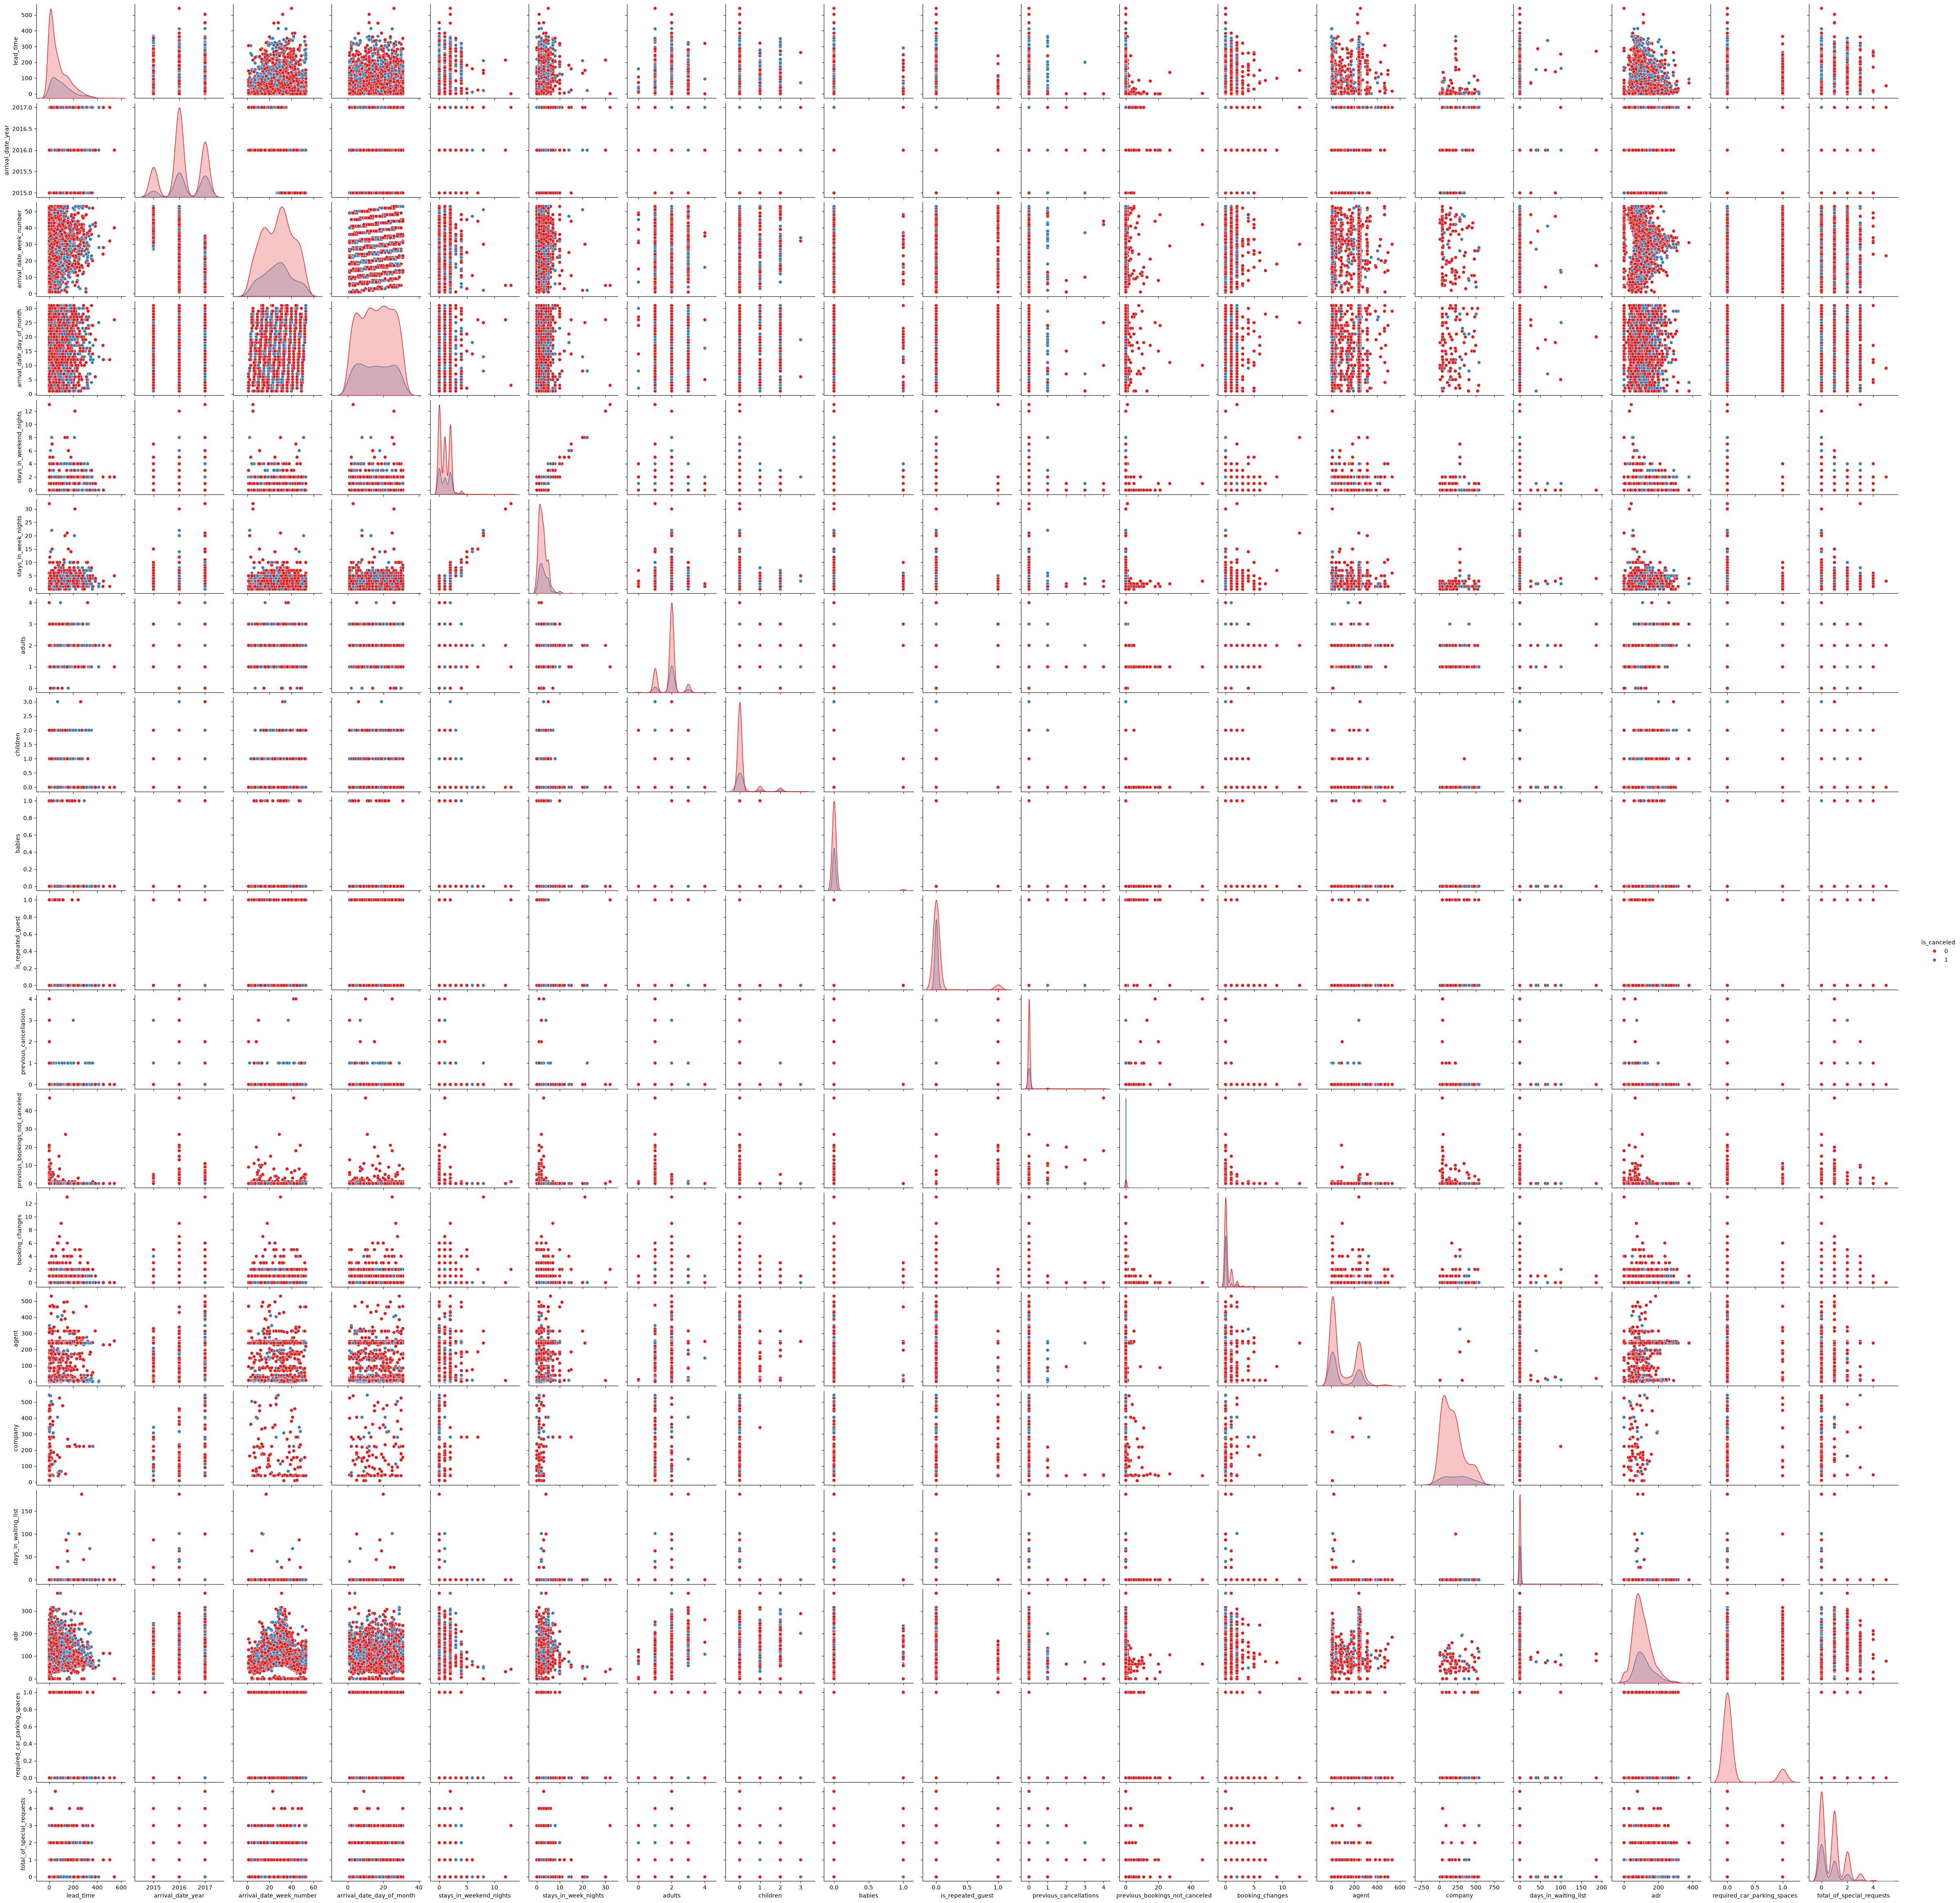

In [28]:
# Hacemos el pairplot usando una muestra para que cargue rápido
sns.pairplot(df_hotel_act.sample(2000, random_state=42), hue='is_canceled', palette='Set1')

### Creación del modelo
```python
from sklearn.linear_model import LogisticRegression
```

In [51]:
# Seleccionamos las columnas independientes
list_columnas_independientes = df_iris.drop(columns=target_column).columns.to_list()
list_columnas_independientes

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [57]:
# Preparación de los datos para el modelo de regresión logística
X = df_iris[list_columnas_independientes]
y = df_iris[target_column]

In [59]:
# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=422)

In [60]:
# Creación del modelo de regresión logística
modelo_rl = LogisticRegression(max_iter=200, random_state=42)
modelo_rl.fit(X_train, y_train)

LogisticRegression(max_iter=200, random_state=42)

In [61]:
# Obtenemos la predicción del modelo
y_pred = modelo_rl.predict(X_test)

### Evaluación del modelo
Evaluaremos el modelo utilizando el accuracy (exactitud) y por otro lado veremos la matriz de confusión:
+ Accuracy: representa el porcentaje de aciertos respecto al total de las predicciones
+ Matriz de confusión: muestra de una manera visualuna tabla que compara las predicciones de un modelo respecto con los valores reales, verdaderos positivos (true positive) y verdaderos falsos (true false).

La fórmula del accuracy es la siguiente:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
Donde:
  + TP = Verdaderos Positivos (True Positives)
  + TN = Verdaderos Negativos (True Negatives)
  + FP = Falsos Positivos (False Positives)
  + FN = Falsos Negativos (False Negatives)

Para ello será necesario importar las siguientes funciones:

```python
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
```

In [65]:
len(y_pred)

30

In [67]:
# Evaluamos el modelo usando el accuracy (exactitud)
acc = accuracy_score(y_test, y_pred)
print(acc)

0.9


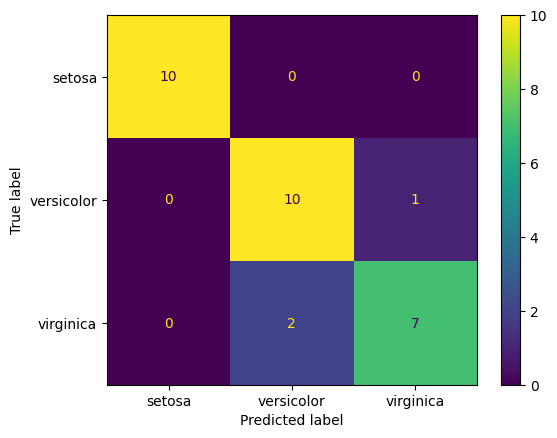

In [72]:
# Generamos una matriz de confusión que permitirá ver cuántas son las predicciones correctas y cuántas incorrectas
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot()

## 2. Regresión logística para clasificación binaria
Ahora veremos el caso de una regresión logística pero en este caso aplicándolo para un problma de clasificación binaria (sólo 2 clases). Donde utilizaremos otro dataset común llamado `heart_disease`, lo leeremos directamente del directorio `./data/heart_disease.csv`.

| Variable | Descripción | Tipo |
| -------- | ----------- | ---- |
| age | Edad del paciente | Numérico |
| sex | Sexo (1 = hombre, 0 = mujer) | Binario |
| cp | Tipo de dolor en el pecho (0-3) | Categórico |
| trestbps | Presión arterial en reposo | Numérico |
| chol | Colesterol sérico (mg/dl) | Numérico |
| fbs | Glucemia en ayunas (>120 mg/dl) (1 = sí) | Binario |
| restecg | Resultados electrocardiográficos en reposo | Categórico |
| thalach | Frecuencia cardíaca máxima alcanzada | Numérico |
| exang | Angina inducida por ejercicio (1 = sí) | Binario |
| oldpeak | Depresión del ST inducida por ejercicio | Numérico |
| slope | Pendiente del segmento ST en esfuerzo | Categórico |
| ca | Número de vasos principales (0-3) | Numérico |
| thal | Resultado de la prueba de talio (1,2,3) | Categórico |
| target | Enfermedad cardíaca (1 = Sí, 0 = No) | Binario |

### Lectura de datos

In [39]:
df_heart = pd.read_csv(PATH_DATASET_HEART)

### Preprocesamiento de datos

In [40]:
# Mostramos las primeras filas del DataFrame


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [41]:
# Mostramos las dimensiones del DataFrame


(303, 14)

In [42]:
# Mostramos información del DataFrame


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [43]:
# Convertimos las columnas que deberían ser categóricas a tipo string además del target
dict_astype_heart = 



In [44]:
# Reemplzamos los valores numéricos de la columna 'target' por los nombres de las clases
dict_target_heart = 


In [46]:
# Descripción estadística de todas las columnas


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,303.0,NaN,NaN,NaN,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,NaN,NaN,NaN,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303,4,0,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,303.0,NaN,NaN,NaN,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,NaN,NaN,NaN,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,NaN,NaN,NaN,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303,3,1,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalach,303.0,NaN,NaN,NaN,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,NaN,NaN,NaN,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,NaN,NaN,NaN,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [47]:
# Vemos las frecuencias absolutas de la columna 'target'


target
Enfermedad       165
No enfermedad    138
Name: count, dtype: int64

In [48]:
# Ahora vemos las frecuencias relativas


target
Enfermedad       0.544554
No enfermedad    0.455446
Name: proportion, dtype: float64

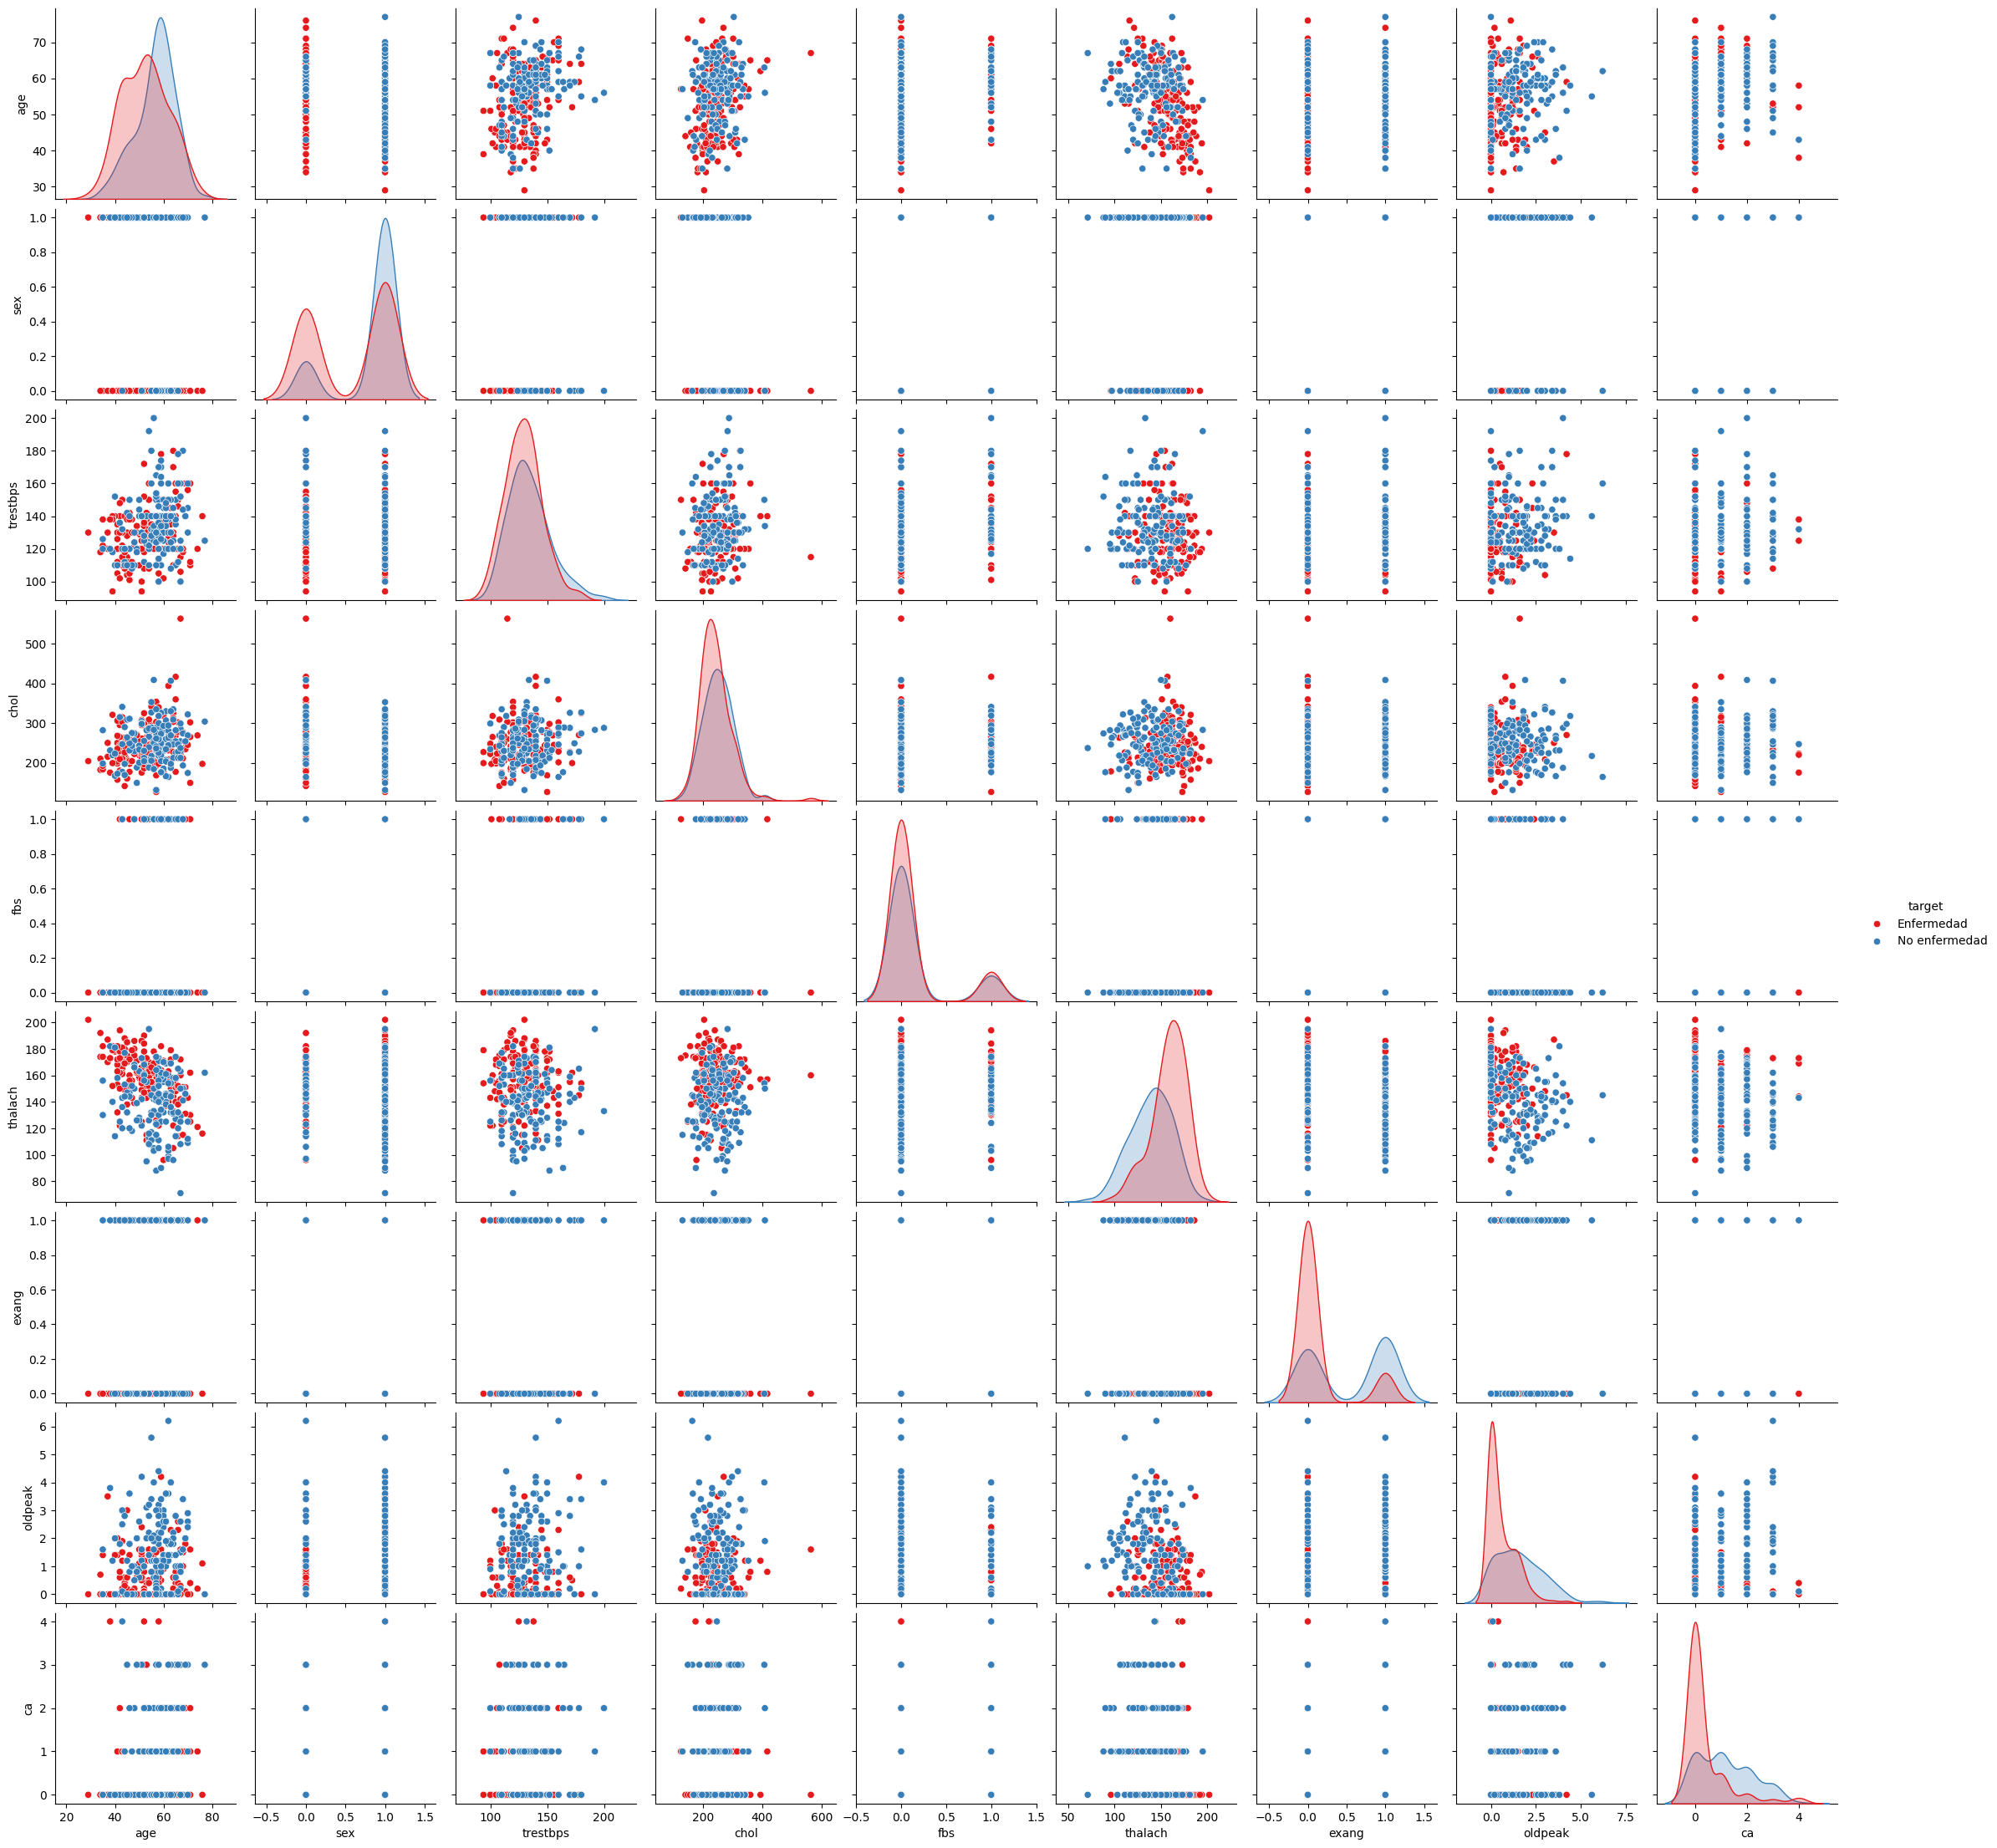

In [49]:
# Hacemos un gráfico de dispersión de las variables numéricas


### Creación del modelo y ajuste

In [51]:
# Preparación de los datos para el modelo de regresión logística
# Eliminamos la columna 'target' de las variables independientes
# Y transformamos a numérico la columna target
X_heart = 
y_heart = 